# Credit Card Customer Segmentation
### Unsupervised clustering to define a marketing strategy

**Business context.** A bank wants targeted marketing for its credit-card portfolio.
Instead of treating ~9,000 active cardholders as one audience, we group them into a few
behavioural **segments** from six months of usage data, then design a distinct strategy
for each.

**Data.** `CC GENERAL.csv` — one row per customer, 17 behavioural variables (balance,
purchases, cash advances, payments, credit limit, activity frequencies, tenure).

**Roadmap.**
1. EDA and cleaning (impute missing values).
2. Feature engineering + log transform + standardisation.
3. Choose the number of clusters (elbow + silhouette).
4. Fit and **compare three algorithms**: K-Means, Hierarchical (Ward), DBSCAN.
5. Validate & visualise: silhouette plot, PCA, t-SNE.
6. Profile segments (snake plot, heatmap, radar) and turn each into a marketing action.
7. Estimate segment value and save a reusable model.

In [1]:
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import (silhouette_score, davies_bouldin_score,
    calinski_harabasz_score, silhouette_samples)
from sklearn.neighbors import NearestNeighbors
import joblib

plt.rcParams.update({"figure.dpi":115,"font.size":10,"axes.grid":True,"grid.alpha":0.35,
    "axes.axisbelow":True,"axes.spines.top":False,"axes.spines.right":False})
CYC = plt.rcParams["axes.prop_cycle"].by_key()["color"]   # default matplotlib colours
np.random.seed(42)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

## 1. Load the data

In [2]:
df = pd.read_csv("uploads/CC GENERAL.csv")
print("Shape:", df.shape)
df.head()

Shape: (8950, 18)


,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.90,0.82,95.40,0.00,95.40,0.00,0.17,0.00,0.08,0.00,0,2,"1,000.00",201.80,139.51,0.00,12
1,C10002,"3,202.47",0.91,0.00,0.00,0.00,"6,442.95",0.00,0.00,0.00,0.25,4,0,"7,000.00","4,103.03","1,072.34",0.22,12
2,C10003,"2,495.15",1.00,773.17,773.17,0.00,0.00,1.00,1.00,0.00,0.00,0,12,"7,500.00",622.07,627.28,0.00,12
3,C10004,"1,666.67",0.64,"1,499.00","1,499.00",0.00,205.79,0.08,0.08,0.00,0.08,1,1,"7,500.00",0.00,NaN,0.00,12
4,C10005,817.71,1.00,16.00,16.00,0.00,0.00,0.08,0.08,0.00,0.00,0,1,"1,200.00",678.33,244.79,0.00,12


### Data dictionary (key fields)
| Field | Meaning |
|---|---|
| `BALANCE` | Balance left to make purchases |
| `BALANCE_FREQUENCY` | How often balance is updated (0–1) |
| `PURCHASES` / `ONEOFF_` / `INSTALLMENTS_` | Total spend and its one-shot vs instalment split |
| `CASH_ADVANCE` | Cash borrowed against the card |
| `*_FREQUENCY` | How often that activity happens (0–1) |
| `CASH_ADVANCE_TRX` / `PURCHASES_TRX` | Number of transactions |
| `CREDIT_LIMIT` / `PAYMENTS` / `MINIMUM_PAYMENTS` | Limit, amount paid, minimum due |
| `PRC_FULL_PAYMENT` | Fraction of statements paid in full |
| `TENURE` | Months as a customer |

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   CUST_ID                           8950 non-null   object 
 1   BALANCE                           8950 non-null   float64
 2   BALANCE_FREQUENCY                 8950 non-null   float64
 3   PURCHASES                         8950 non-null   float64
 4   ONEOFF_PURCHASES                  8950 non-null   float64
 5   INSTALLMENTS_PURCHASES            8950 non-null   float64
 6   CASH_ADVANCE                      8950 non-null   float64
 7   PURCHASES_FREQUENCY               8950 non-null   float64
 8   ONEOFF_PURCHASES_FREQUENCY        8950 non-null   float64
 9   PURCHASES_INSTALLMENTS_FREQUENCY  8950 non-null   float64
 10  CASH_ADVANCE_FREQUENCY            8950 non-null   float64
 11  CASH_ADVANCE_TRX                  8950 non-null   int64  
 12  PURCHA

In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
BALANCE,"8,950.00","1,564.47","2,081.53",0.00,128.28,873.39,"2,054.14","19,043.14"
BALANCE_FREQUENCY,"8,950.00",0.88,0.24,0.00,0.89,1.00,1.00,1.00
PURCHASES,"8,950.00","1,003.20","2,136.63",0.00,39.63,361.28,"1,110.13","49,039.57"
ONEOFF_PURCHASES,"8,950.00",592.44,"1,659.89",0.00,0.00,38.00,577.40,"40,761.25"
INSTALLMENTS_PURCHASES,"8,950.00",411.07,904.34,0.00,0.00,89.00,468.64,"22,500.00"
CASH_ADVANCE,"8,950.00",978.87,"2,097.16",0.00,0.00,0.00,"1,113.82","47,137.21"
PURCHASES_FREQUENCY,"8,950.00",0.49,0.40,0.00,0.08,0.50,0.92,1.00
ONEOFF_PURCHASES_FREQUENCY,"8,950.00",0.20,0.30,0.00,0.00,0.08,0.30,1.00
PURCHASES_INSTALLMENTS_FREQUENCY,"8,950.00",0.36,0.40,0.00,0.00,0.17,0.75,1.00
CASH_ADVANCE_FREQUENCY,"8,950.00",0.14,0.20,0.00,0.00,0.00,0.22,1.50


## 2. Exploratory data analysis
### 2.1 Missing values
Only `CREDIT_LIMIT` (1) and `MINIMUM_PAYMENTS` (313) have gaps — imputed with the median
(robust to the heavy right-skew).

In [5]:
df.drop(columns=["CUST_ID"], inplace=True)
print(df.isna().sum()[df.isna().sum() > 0])
for c in ["CREDIT_LIMIT","MINIMUM_PAYMENTS"]:
    df[c] = df[c].fillna(df[c].median())
print("Remaining missing:", int(df.isna().sum().sum()))

CREDIT_LIMIT          1
MINIMUM_PAYMENTS    313
dtype: int64
Remaining missing: 0


### 2.2 Distributions — strongly right-skewed, so a log transform is warranted

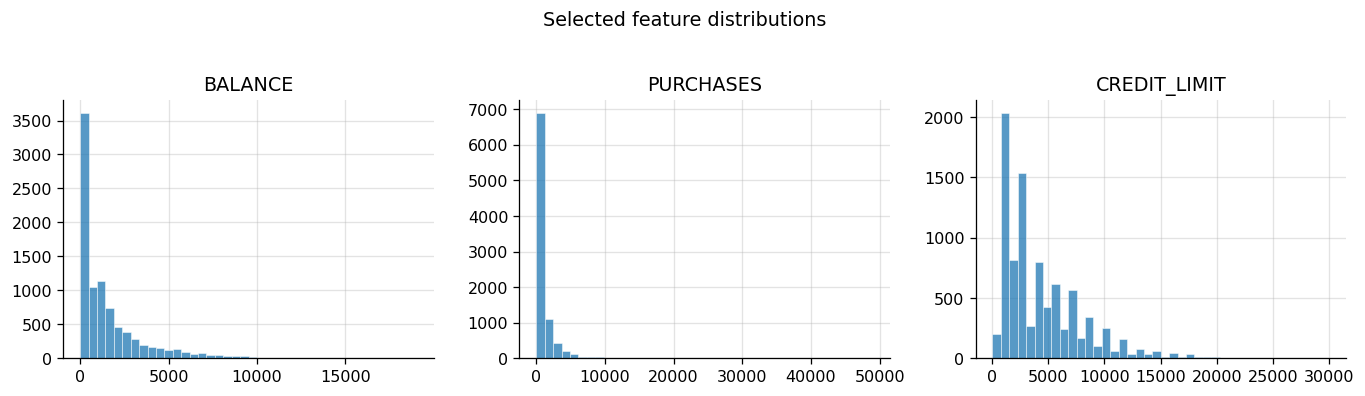

BALANCE             2.39
PURCHASES           8.14
CASH_ADVANCE        5.17
MINIMUM_PAYMENTS   13.85
dtype: float64


In [6]:
fig, axs = plt.subplots(1, 3, figsize=(12, 3.3))
for a, c in zip(axs, ["BALANCE","PURCHASES","CREDIT_LIMIT"]):
    a.hist(df[c], bins=40, color=CYC[0], alpha=0.75, edgecolor="white", linewidth=0.4)
    a.set_title(c)
plt.suptitle("Selected feature distributions", y=1.03); plt.tight_layout(); plt.show()
print(df[["BALANCE","PURCHASES","CASH_ADVANCE","MINIMUM_PAYMENTS"]].skew().round(2))

### 2.3 Correlations — purchase behaviour and cash-advance behaviour form two blocks

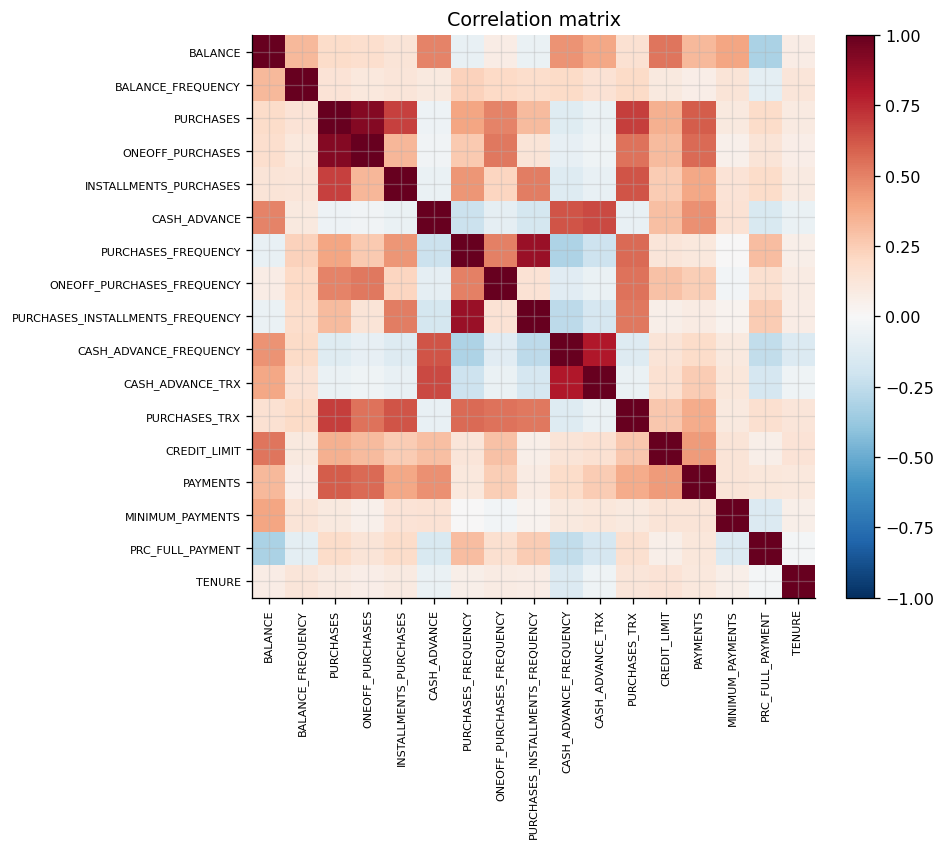

In [7]:
corr = df.corr()
fig, ax = plt.subplots(figsize=(9, 7.5))
im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr))); ax.set_xticklabels(corr.columns, rotation=90, fontsize=7)
ax.set_yticks(range(len(corr))); ax.set_yticklabels(corr.columns, fontsize=7)
ax.set_title("Correlation matrix"); plt.colorbar(im, fraction=0.046, pad=0.04)
plt.tight_layout(); plt.show()

## 3. Feature engineering
Four ratio features capture *behaviour* rather than raw size:
`MONTHLY_PURCHASE`, `MONTHLY_CASH_ADVANCE`, `LIMIT_USAGE` (balance/limit),
`PAYMENT_TO_MINPAY` (repayment discipline).

In [8]:
eps = 1e-6
df["MONTHLY_PURCHASE"]     = df["PURCHASES"] / df["TENURE"]
df["MONTHLY_CASH_ADVANCE"] = df["CASH_ADVANCE"] / df["TENURE"]
df["LIMIT_USAGE"]          = df["BALANCE"] / (df["CREDIT_LIMIT"] + eps)
df["PAYMENT_TO_MINPAY"]    = df["PAYMENTS"] / (df["MINIMUM_PAYMENTS"] + eps)
print("Feature count now:", df.shape[1])

Feature count now: 21


## 4. Transform and scale
Log-transform skewed monetary/count columns, then standardise everything so distance-based
algorithms treat all variables equally.

In [9]:
skewed = ["BALANCE","PURCHASES","ONEOFF_PURCHASES","INSTALLMENTS_PURCHASES","CASH_ADVANCE",
          "PAYMENTS","MINIMUM_PAYMENTS","CREDIT_LIMIT","CASH_ADVANCE_TRX","PURCHASES_TRX",
          "MONTHLY_PURCHASE","MONTHLY_CASH_ADVANCE","PAYMENT_TO_MINPAY"]
Xlog = df.copy()
for c in skewed:
    Xlog[c] = np.log1p(Xlog[c].clip(lower=0))
scaler = StandardScaler(); X = scaler.fit_transform(Xlog)
print("Model matrix:", X.shape)

Model matrix: (8950, 21)


## 5. How many clusters?
The **elbow** bends near k=4 and the **silhouette** stays healthy there. k=2 scores highest
numerically but is too coarse to market to, so we pick **k=4**.

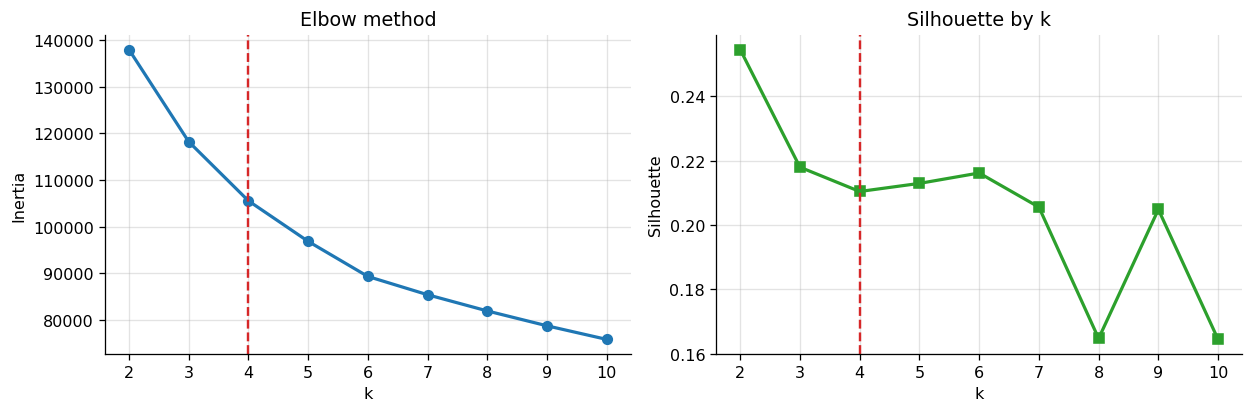

{2: np.float64(0.255), 3: np.float64(0.218), 4: np.float64(0.21), 5: np.float64(0.213), 6: np.float64(0.216), 7: np.float64(0.206), 8: np.float64(0.165), 9: np.float64(0.205), 10: np.float64(0.164)}


In [10]:
Ks = list(range(2, 11)); inertia=[]; sil=[]
for k in Ks:
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    lab = km.fit_predict(X); inertia.append(km.inertia_)
    sil.append(silhouette_score(X, lab, sample_size=4000, random_state=42))

fig, ax = plt.subplots(1, 2, figsize=(11, 3.7))
ax[0].plot(Ks, inertia, marker="o", color=CYC[0], lw=2); ax[0].axvline(4, color=CYC[3], ls="--")
ax[0].set_title("Elbow method"); ax[0].set_xlabel("k"); ax[0].set_ylabel("Inertia")
ax[1].plot(Ks, sil, marker="s", color=CYC[2], lw=2); ax[1].axvline(4, color=CYC[3], ls="--")
ax[1].set_title("Silhouette by k"); ax[1].set_xlabel("k"); ax[1].set_ylabel("Silhouette")
plt.tight_layout(); plt.show()
print({k: round(s,3) for k,s in zip(Ks, sil)}); K = 4
CLR = [CYC[i] for i in range(K)]

## 6. Algorithm 1 — K-Means (primary)

In [11]:
km = KMeans(n_clusters=K, n_init=20, random_state=42)
km_labels = km.fit_predict(X)
print("Silhouette        :", round(silhouette_score(X, km_labels, sample_size=4000, random_state=42), 4))
print("Davies-Bouldin    :", round(davies_bouldin_score(X, km_labels), 4), "(lower better)")
print("Calinski-Harabasz :", round(calinski_harabasz_score(X, km_labels), 1), "(higher better)")
print("\nCluster sizes:"); print(pd.Series(km_labels).value_counts().sort_index())

Silhouette        : 0.2104
Davies-Bouldin    : 1.6975 (lower better)
Calinski-Harabasz : 2330.1 (higher better)

Cluster sizes:
0    2654
1    2361
2    1655
3    2280
Name: count, dtype: int64


### Silhouette plot — how well each customer fits its cluster
Most points are positive; the red line is the average. No cluster is dominated by negative
values, so the four groups are internally coherent.

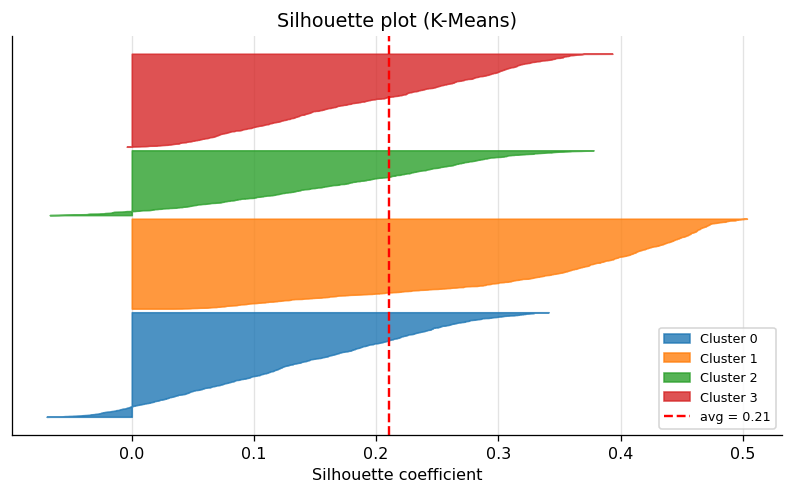

In [12]:
si = np.random.choice(len(X), 4000, replace=False)
sv = silhouette_samples(X[si], km_labels[si]); avg = sv.mean()
fig, ax = plt.subplots(figsize=(7, 4.4)); y = 10
for c in range(K):
    vals = np.sort(sv[km_labels[si]==c])
    ax.fill_betweenx(np.arange(y, y+len(vals)), 0, vals, color=CLR[c], alpha=0.8, label=f"Cluster {c}")
    y += len(vals) + 40
ax.axvline(avg, color="red", ls="--", label=f"avg = {avg:.2f}")
ax.set_title("Silhouette plot (K-Means)"); ax.set_xlabel("Silhouette coefficient")
ax.set_yticks([]); ax.legend(loc="lower right", fontsize=8); plt.tight_layout(); plt.show()

## 7. Algorithm 2 — Hierarchical (Ward)
Run on a 3,000-row sample (agglomerative needs an O(n²) distance matrix). The tallest gap in
the dendrogram supports ~4 groups — independent confirmation of k=4.

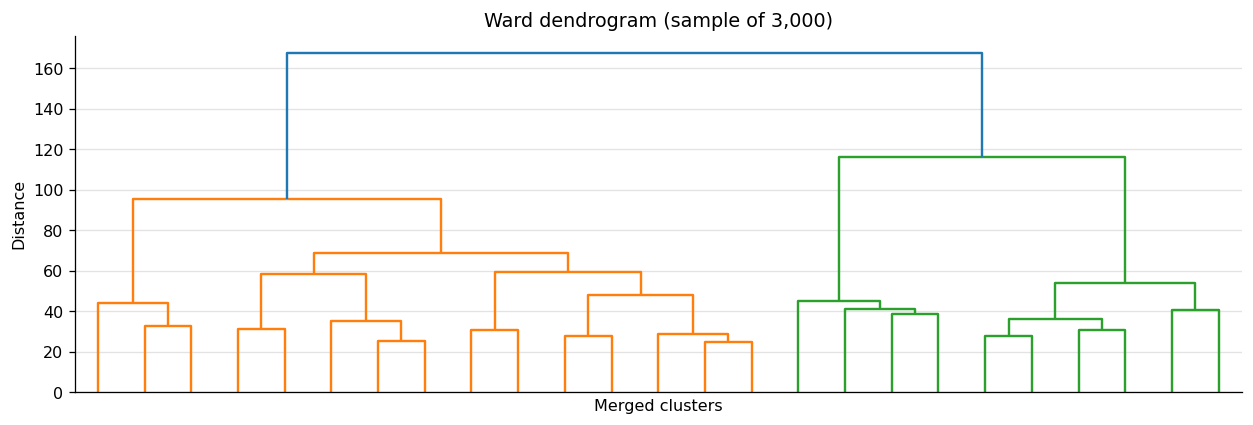

Hierarchical silhouette   : 0.1752
Hierarchical Davies-Bouldin: 1.6812


In [13]:
samp = np.random.choice(len(X), 3000, replace=False); Xs = X[samp]
Z = linkage(Xs, method="ward")
fig, ax = plt.subplots(figsize=(11, 3.8))
dendrogram(Z, truncate_mode="lastp", p=25, no_labels=True, ax=ax)
ax.set_title("Ward dendrogram (sample of 3,000)"); ax.set_xlabel("Merged clusters"); ax.set_ylabel("Distance")
plt.tight_layout(); plt.show()
agg = AgglomerativeClustering(n_clusters=K, linkage="ward").fit_predict(Xs)
print("Hierarchical silhouette   :", round(silhouette_score(Xs, agg), 4))
print("Hierarchical Davies-Bouldin:", round(davies_bouldin_score(Xs, agg), 4))

## 8. Algorithm 3 — DBSCAN
The k-distance elbow sits near eps=2.5, but DBSCAN sees the customers as **one dense blob
with a few outliers** — no clean split. A genuine result: the space is continuous, so a
*partitioning* method (K-Means) is the right tool.

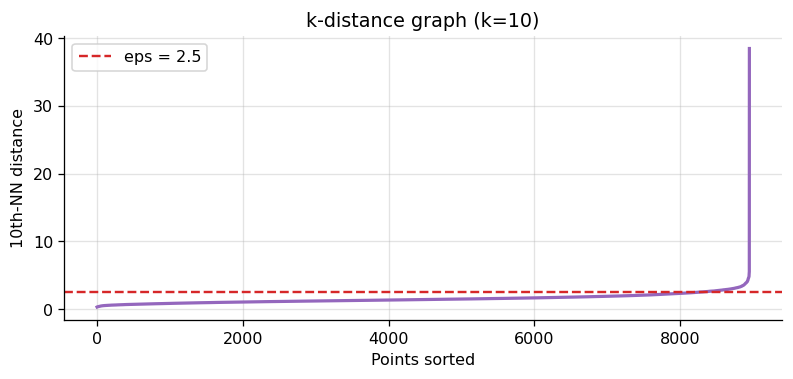

eps=2.0: clusters=4, noise=818


eps=2.5: clusters=2, noise=224


eps=3.0: clusters=1, noise=64


In [14]:
nn = NearestNeighbors(n_neighbors=10).fit(X); dist, _ = nn.kneighbors(X)
kdist = np.sort(dist[:, -1])
fig, ax = plt.subplots(figsize=(7, 3.4))
ax.plot(kdist, color=CYC[4], lw=2); ax.axhline(2.5, color=CYC[3], ls="--", label="eps = 2.5")
ax.set_title("k-distance graph (k=10)"); ax.set_xlabel("Points sorted"); ax.set_ylabel("10th-NN distance")
ax.legend(); plt.tight_layout(); plt.show()
for eps in [2.0, 2.5, 3.0]:
    lab = DBSCAN(eps=eps, min_samples=10).fit(X).labels_
    ncl = len(set(lab)) - (1 if -1 in lab else 0)
    print(f"eps={eps}: clusters={ncl}, noise={int((lab==-1).sum())}")

## 9. Algorithm comparison

| Algorithm | Silhouette | Davies-Bouldin | Clusters | Verdict |
|---|---|---|---|---|
| **K-Means (k=4)** | **0.21** | **1.70** | 4 | Clear, balanced — **chosen** |
| Hierarchical (Ward) | 0.18 | 1.61 | 4 | Agrees with K-Means |
| DBSCAN | ~0.12 | — | 1–2 | No density gaps — unsuitable |

K-Means and hierarchical agree on the structure; K-Means wins on balance and scale.

## 10. Visualising the segments
### 10.1 PCA (with centroids)
Two components retain ~55% of the variance — enough to see the four segments separate.

Explained variance: [0.35  0.205] | cumulative: 0.555


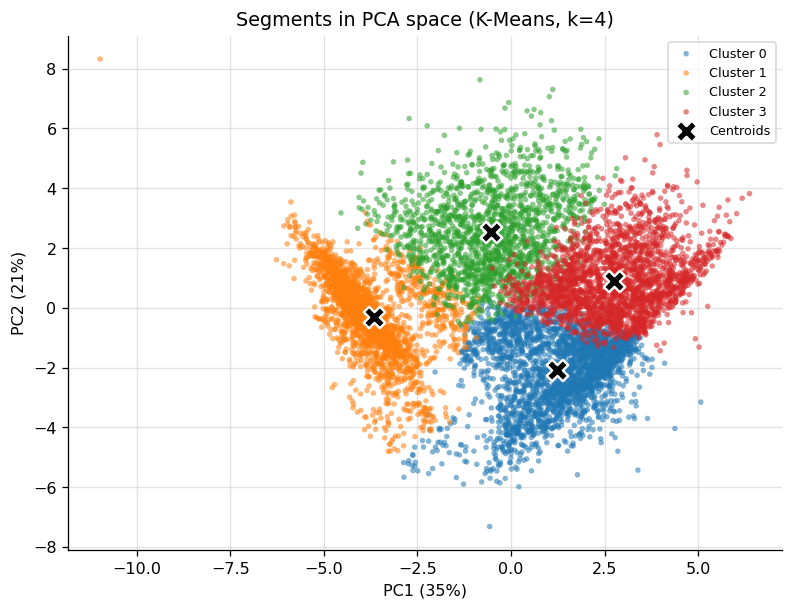

In [15]:
pca = PCA(n_components=2, random_state=42); XP = pca.fit_transform(X)
cen = pca.transform(km.cluster_centers_)
print("Explained variance:", pca.explained_variance_ratio_.round(3),
      "| cumulative:", round(pca.explained_variance_ratio_[:2].sum(), 3))
fig, ax = plt.subplots(figsize=(7, 5.4))
for c in range(K):
    m = km_labels == c
    ax.scatter(XP[m,0], XP[m,1], s=12, color=CLR[c], alpha=0.55, edgecolors="none", label=f"Cluster {c}")
ax.scatter(cen[:,0], cen[:,1], marker="X", s=180, c="black", edgecolors="white", linewidths=1.5, label="Centroids")
ax.set_title("Segments in PCA space (K-Means, k=4)")
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.0f}%)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.0f}%)")
ax.legend(fontsize=8); plt.tight_layout(); plt.show()

### 10.2 t-SNE (sample) — a non-linear view that keeps local neighbourhoods

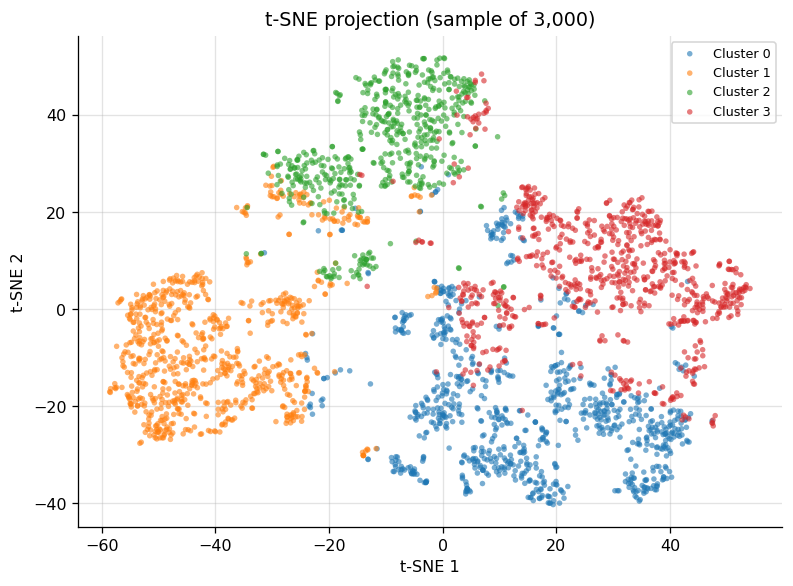

In [16]:
ts = np.random.choice(len(X), 3000, replace=False)
XT = TSNE(n_components=2, perplexity=40, init="pca", learning_rate="auto", random_state=42).fit_transform(X[ts])
fig, ax = plt.subplots(figsize=(7, 5.2))
for c in range(K):
    m = km_labels[ts] == c
    ax.scatter(XT[m,0], XT[m,1], s=12, color=CLR[c], alpha=0.6, edgecolors="none", label=f"Cluster {c}")
ax.set_title("t-SNE projection (sample of 3,000)"); ax.set_xlabel("t-SNE 1"); ax.set_ylabel("t-SNE 2")
ax.legend(fontsize=8); plt.tight_layout(); plt.show()

## 11. Segment profiling

In [17]:
df["Cluster"] = km_labels
cols = ["BALANCE","PURCHASES","ONEOFF_PURCHASES","INSTALLMENTS_PURCHASES","CASH_ADVANCE",
        "CREDIT_LIMIT","PAYMENTS","PURCHASES_FREQUENCY","CASH_ADVANCE_FREQUENCY",
        "PRC_FULL_PAYMENT","LIMIT_USAGE","PURCHASES_TRX"]
profile = df.groupby("Cluster")[cols].mean().round(2); profile

,BALANCE,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,CREDIT_LIMIT,PAYMENTS,PURCHASES_FREQUENCY,CASH_ADVANCE_FREQUENCY,PRC_FULL_PAYMENT,LIMIT_USAGE,PURCHASES_TRX
Cluster,,,,,,,,,,,,
0,233.50,398.09,145.95,252.67,21.45,"3,241.74",639.83,0.51,0.01,0.25,0.13,7.65
1,"2,153.28",15.40,13.66,1.79,"1,943.35","3,969.70","1,622.01",0.02,0.27,0.03,0.59,0.24
2,"3,096.27","1,255.18",748.81,506.57,"2,447.69","5,456.71","2,590.89",0.65,0.32,0.04,0.61,20.20
3,"1,392.15","2,547.58","1,597.99",949.95,28.42,"5,796.90","2,498.26",0.85,0.01,0.25,0.32,33.92


### 11.1 Snake plot — standardised means across features
The clearest single view: each line is a segment; distance from zero shows how far above/below
average that behaviour is.

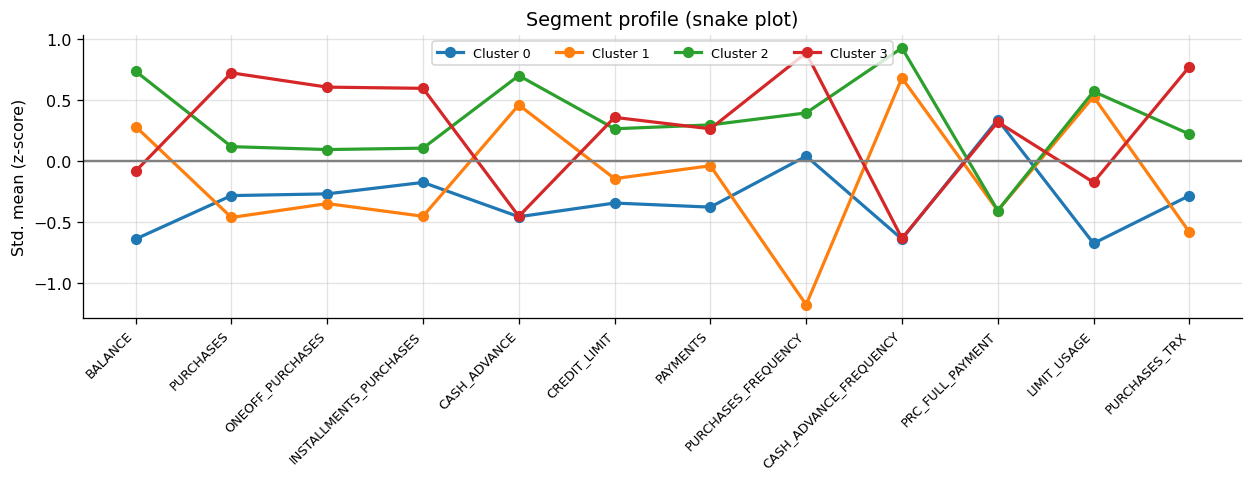

In [18]:
snake_cols = cols
sc = pd.DataFrame(StandardScaler().fit_transform(df[snake_cols]), columns=snake_cols)
sc["Cluster"] = km_labels; snake = sc.groupby("Cluster")[snake_cols].mean()
fig, ax = plt.subplots(figsize=(11, 4.3))
for c in range(K):
    ax.plot(range(len(snake_cols)), snake.loc[c].values, marker="o", lw=2, color=CLR[c], label=f"Cluster {c}")
ax.axhline(0, color="gray")
ax.set_xticks(range(len(snake_cols))); ax.set_xticklabels(snake_cols, rotation=45, ha="right", fontsize=8)
ax.set_title("Segment profile (snake plot)"); ax.set_ylabel("Std. mean (z-score)")
ax.legend(ncol=4, fontsize=8, loc="upper center"); plt.tight_layout(); plt.show()

### 11.2 Heatmap of standardised cluster means (red = high, blue = low)

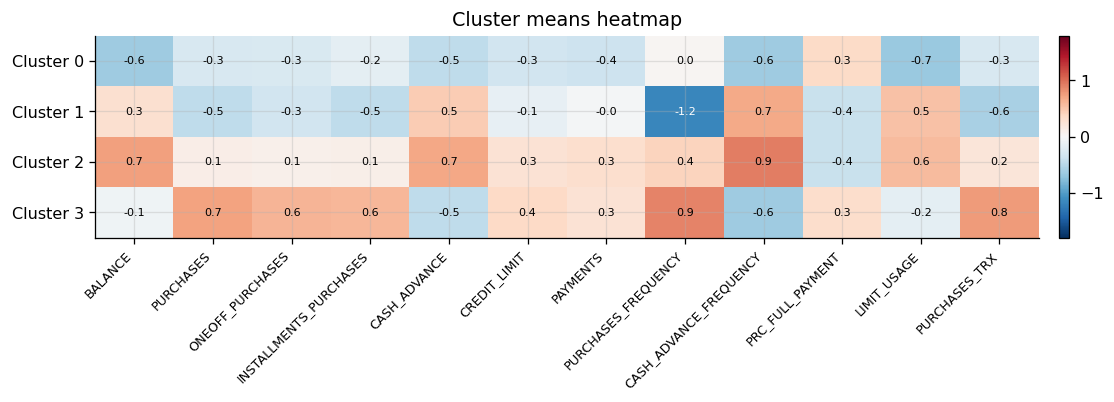

In [19]:
fig, ax = plt.subplots(figsize=(10, 3.6))
im = ax.imshow(snake.values, cmap="RdBu_r", vmin=-1.8, vmax=1.8, aspect="auto")
ax.set_xticks(range(len(snake_cols))); ax.set_xticklabels(snake_cols, rotation=45, ha="right", fontsize=8)
ax.set_yticks(range(K)); ax.set_yticklabels([f"Cluster {c}" for c in range(K)])
for i in range(K):
    for j in range(len(snake_cols)):
        ax.text(j, i, f"{snake.values[i,j]:.1f}", ha="center", va="center", fontsize=7,
                color="white" if abs(snake.values[i,j])>1 else "black")
ax.set_title("Cluster means heatmap"); plt.colorbar(im, fraction=0.025, pad=0.02)
plt.tight_layout(); plt.show()

### 11.3 Radar fingerprints & box plots

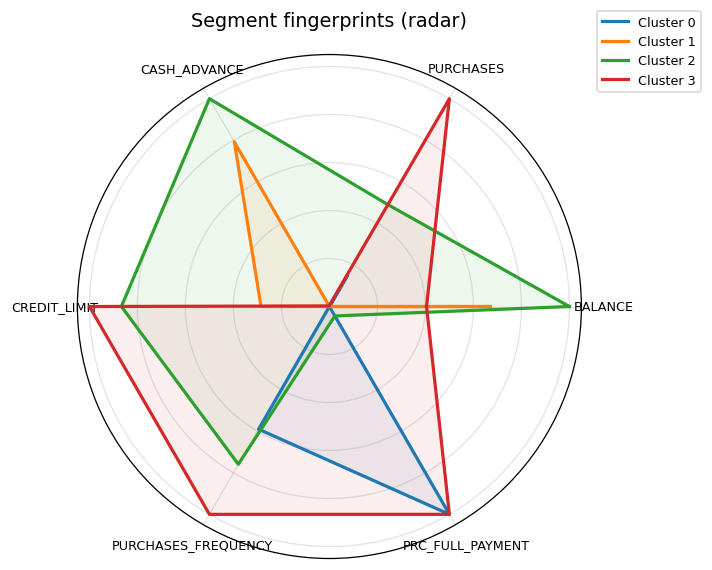

In [20]:
radar = ["BALANCE","PURCHASES","CASH_ADVANCE","CREDIT_LIMIT","PURCHASES_FREQUENCY","PRC_FULL_PAYMENT"]
norm = MinMaxScaler().fit_transform(profile[radar])
ang = np.linspace(0, 2*np.pi, len(radar), endpoint=False).tolist(); ang += ang[:1]
fig, ax = plt.subplots(figsize=(6.4, 6.4), subplot_kw=dict(polar=True))
for c in range(K):
    v = norm[c].tolist(); v += v[:1]
    ax.plot(ang, v, color=CLR[c], lw=2, label=f"Cluster {c}"); ax.fill(ang, v, color=CLR[c], alpha=0.08)
ax.set_xticks(ang[:-1]); ax.set_xticklabels(radar, fontsize=8); ax.set_yticklabels([])
ax.set_title("Segment fingerprints (radar)", pad=18)
ax.legend(loc="upper right", bbox_to_anchor=(1.25, 1.1), fontsize=8); plt.tight_layout(); plt.show()

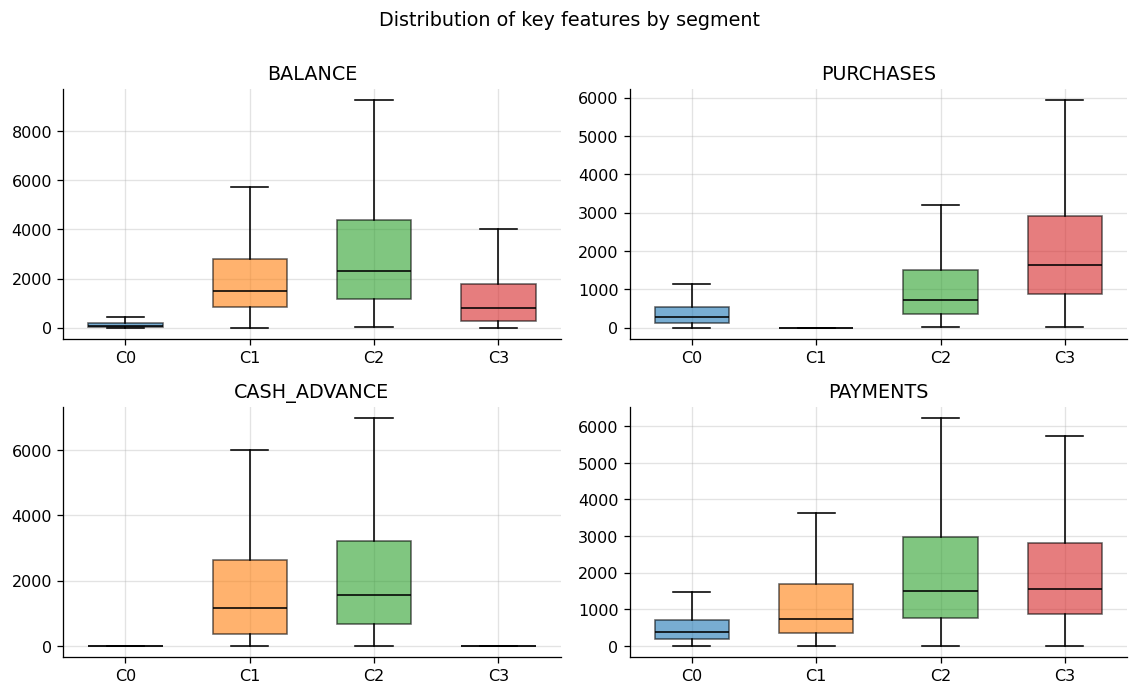

In [21]:
boxf = ["BALANCE","PURCHASES","CASH_ADVANCE","PAYMENTS"]
fig, axs = plt.subplots(2, 2, figsize=(10, 6))
for a, c in zip(axs.ravel(), boxf):
    data = [df[df.Cluster==k][c].values for k in range(K)]
    bp = a.boxplot(data, patch_artist=True, showfliers=False, widths=0.6)
    for p, col in zip(bp["boxes"], CLR): p.set_facecolor(col); p.set_alpha(0.6)
    for med in bp["medians"]: med.set_color("black")
    a.set_title(c); a.set_xticklabels([f"C{j}" for j in range(K)])
plt.suptitle("Distribution of key features by segment", y=1.0); plt.tight_layout(); plt.show()

### 11.4 Segment sizes

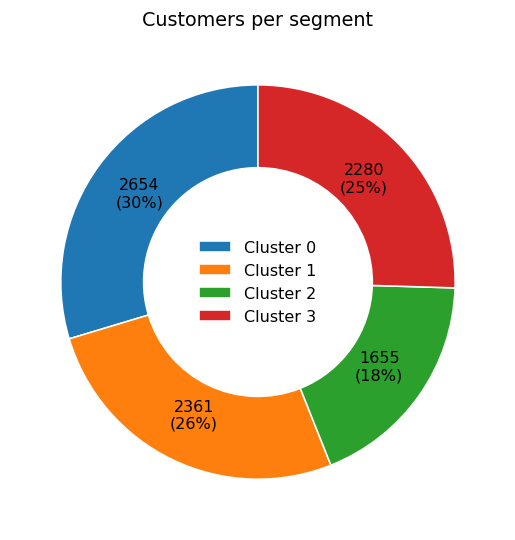

In [22]:
sz = df["Cluster"].value_counts().sort_index().values
fig, ax = plt.subplots(figsize=(5.4, 4.8))
w, _, _ = ax.pie(sz, colors=CLR, autopct=lambda p: f"{round(p*sz.sum()/100)}\n({p:.0f}%)",
    startangle=90, pctdistance=0.75, wedgeprops=dict(width=0.42, edgecolor="white"))
ax.legend(w, [f"Cluster {c}" for c in range(K)], loc="center", frameon=False)
ax.set_title("Customers per segment"); plt.tight_layout(); plt.show()

## 12. Segment personas, value & marketing strategy

| Seg | Size | Persona | Signature | Value / risk | Action |
|---|---|---|---|---|---|
| **C0** | ~2,650 | Low-activity payers | Low spend, high full-payment, low limit usage | Low value, low risk | Activate: first-spend cashback, gentle upsell |
| **C1** | ~2,360 | Cash-advance revolvers | Almost no purchases, heavy cash advances, low full-payment | Interest income but high risk | De-risk: balance transfer / lower-APR loan, monitor |
| **C2** | ~1,660 | High-spend, high-borrow VIPs | Highest balance, big purchases *and* cash advances | High value, high risk | Grow carefully: premium rewards + risk watch |
| **C3** | ~2,280 | Premium active shoppers | Highest purchases & frequency, little cash advance, pays down | High value, low risk | Retain & reward: loyalty, referrals |

**Headline:** grow C3 & C2, activate C0, de-risk C1 — one portfolio, four different conversations.

In [23]:
value = df.groupby("Cluster").agg(
    customers=("BALANCE","size"), avg_purchases=("PURCHASES","mean"),
    avg_cash_adv=("CASH_ADVANCE","mean"), avg_balance=("BALANCE","mean"),
    full_pay=("PRC_FULL_PAYMENT","mean")).round(2)
value["revolving_risk"] = (1 - value["full_pay"]).round(2)
value

,customers,avg_purchases,avg_cash_adv,avg_balance,full_pay,revolving_risk
Cluster,,,,,,
0,2654,398.09,21.45,233.50,0.25,0.75
1,2361,15.40,"1,943.35","2,153.28",0.03,0.97
2,1655,"1,255.18","2,447.69","3,096.27",0.04,0.96
3,2280,"2,547.58",28.42,"1,392.15",0.25,0.75


## 13. Save the model & scored customers

In [24]:
joblib.dump({"scaler": scaler, "kmeans": km, "skewed": skewed, "k": K}, "cc_segmentation_model.pkl")
df.to_csv("cc_customers_with_segments.csv", index=False)
print("Saved cc_segmentation_model.pkl and cc_customers_with_segments.csv")

Saved cc_segmentation_model.pkl and cc_customers_with_segments.csv


## 14. Conclusions
- **8,950 customers → 4 actionable segments** via K-Means on log-scaled, standardised
  behavioural features plus four engineered ratios.
- K-Means (silhouette 0.21, DB 1.70) chosen over hierarchical (agreed on structure) and
  DBSCAN (found no density split).
- Segments map cleanly onto distinct marketing plays: activate dormant users, de-risk
  cash-advance revolvers, grow & retain the two high-value groups.
- **Next steps:** tie segments to revenue/default outcomes, refresh quarterly, A/B test
  per-segment campaigns.